# 05 — Broadband / Frequency-Swept Beamforming

**Goal**: characterise algorithm performance across the full operating
range (200 Hz – 8 kHz) using incoherent octave-band averaging — the
standard output mode for commercial acoustic cameras.

Key questions:
1. How does HPBW scale with frequency for the chosen Underbrink array?
2. Does incoherent octave-band averaging produce stable broadband localisation?
3. Are algorithm rankings (D&S vs MVDR vs MUSIC) consistent across bands?
4. Where does spatial aliasing appear, and how does it manifest?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MIN  = 0.025
R_MAX  = 0.150
N_SNAP = 256
rng    = np.random.default_rng(42)


In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    # Equal arc-length Underbrink multi-arm log-spiral
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)   # H=12 x 8, primary candidate
d_min = np.min([np.sort(np.sqrt((x_arr[i]-x_arr)**2 + (y_arr[i]-y_arr)**2))[1]
                for i in range(len(x_arr))])
f_nyquist = C / (2.0 * d_min)
print(f'N_MICS = {len(x_arr)}')
print(f'Min spacing = {d_min*1e3:.1f} mm')
print(f'Spatial Nyquist = {f_nyquist:.0f} Hz')


N_MICS = 96
Min spacing = 12.9 mm
Spatial Nyquist = 13253 Hz


In [3]:
def steering_vector(x, y, az_deg, freq):
    u = np.sin(np.radians(az_deg))
    phase = 2 * np.pi * freq / C * u * x
    h = np.exp(1j * phase) / np.sqrt(len(x))
    return h


def make_csm(x, y, sources, freq, snr_db=20, n_snap=N_SNAP):
    # sources: list of (az_deg, power_linear) pairs
    N = len(x)
    max_power = max(p for _, p in sources)
    noise_var = max_power / (10 ** (snr_db / 10))
    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for az, power in sources:
            h = steering_vector(x, y, az, freq)
            s = rng.standard_normal() + 1j * rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        noise = rng.standard_normal(N) + 1j * rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap


def beamform_ds(x, y, R, freq, az_grid):
    H = np.array([steering_vector(x, y, az, freq) for az in az_grid]).T  # (N, n_az)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    N = R.shape[0]
    R_loaded = R + diag_load * np.trace(R) / N * np.eye(N)
    R_inv = inv(R_loaded)
    out = np.zeros(len(az_grid))
    for i, az in enumerate(az_grid):
        h = steering_vector(x, y, az, freq)
        denom = np.real(h.conj() @ R_inv @ h)
        out[i] = 1.0 / denom if denom > 0 else 0.0
    return out


def beamform_music(x, y, R, freq, az_grid, n_sources=1):
    _, eigvecs = np.linalg.eigh(R)
    E_n = eigvecs[:, :R.shape[0] - n_sources]
    En_proj = E_n @ E_n.conj().T
    out = np.zeros(len(az_grid))
    for i, az in enumerate(az_grid):
        h = steering_vector(x, y, az, freq)
        denom = np.real(h.conj() @ En_proj @ h)
        out[i] = 1.0 / max(denom, 1e-300)
    return out


def measure_hpbw(az_grid, beam_map):
    # Half-power beamwidth: width at -3dB from peak
    peak = beam_map.max()
    half = peak / 2.0
    above = az_grid[beam_map >= half]
    if len(above) < 2:
        return np.nan
    return above[-1] - above[0]


def db_norm(x):
    # normalise map to dB re peak
    x = np.clip(x, 1e-30, None)
    return 10 * np.log10(x / x.max())


## 1 — HPBW vs Frequency

Resolution (HPBW) is proportional to λ/D.  For our 300 mm-diameter array:

    HPBW ≈ 0.886 · c / (f · D)

This section measures HPBW empirically across the 200 Hz – 16 kHz range
(including beyond our 8 kHz target to show where aliasing begins).


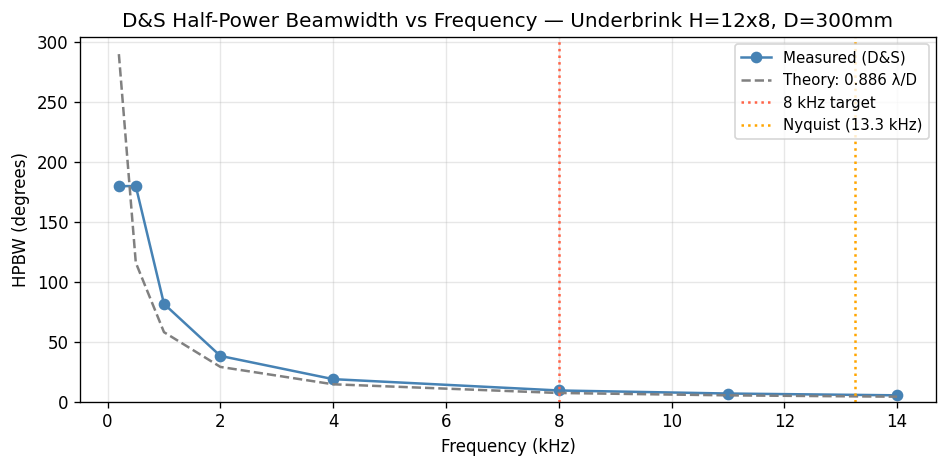

Frequency (Hz)  HPBW (meas)  HPBW (theory)
     200          180.0 deg     290.2 deg
     500          180.0 deg     116.1 deg
    1000           81.7 deg      58.0 deg
    2000           38.2 deg      29.0 deg
    4000           18.8 deg      14.5 deg
    8000            9.3 deg       7.3 deg
   11000            6.8 deg       5.3 deg
   14000            5.3 deg       4.1 deg


In [4]:
az_grid = np.linspace(-90, 90, 3601)
freqs_sweep = np.array([200, 500, 1000, 2000, 4000, 8000, 11000, 14000])

# Single source at 0 deg, high SNR
src_boresight = [(0.0, 1.0)]

hpbw_measured = []
for f in freqs_sweep:
    R = make_csm(x_arr, y_arr, src_boresight, f, snr_db=30)
    m = beamform_ds(x_arr, y_arr, R, f, az_grid)
    hpbw_measured.append(measure_hpbw(az_grid, m))

D_aperture = 2 * R_MAX  # 0.3 m diameter
hpbw_theory = np.degrees(0.886 * C / (freqs_sweep * D_aperture))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_sweep / 1e3, hpbw_measured, 'o-', label='Measured (D&S)', color='steelblue')
ax.plot(freqs_sweep / 1e3, hpbw_theory, '--', label='Theory: 0.886 λ/D', color='gray')
ax.axvline(8, color='tomato', linestyle=':', linewidth=1.5, label='8 kHz target')
ax.axvline(f_nyquist / 1e3, color='orange', linestyle=':', linewidth=1.5,
           label=f'Nyquist ({f_nyquist/1e3:.1f} kHz)')
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('HPBW (degrees)')
ax.set_title('D&S Half-Power Beamwidth vs Frequency — Underbrink H=12x8, D=300mm')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig('bb_hpbw_vs_freq.png', dpi=150, bbox_inches='tight')
plt.show()

print('Frequency (Hz)  HPBW (meas)  HPBW (theory)')
for f, hm, ht in zip(freqs_sweep, hpbw_measured, hpbw_theory):
    print(f'  {f:>6}         {hm:>6.1f} deg     {ht:>5.1f} deg')


## 2 — Incoherent Octave-Band Averaging

A real acoustic camera produces one map per octave (or 1/3-octave) band,
not a single-frequency map.  The map is built by:

1. Splitting the audio into frequency bins (FFT)
2. Estimating the CSM at each bin: `R(f)`
3. Running the beamformer at each bin: `P(θ, f)`
4. Averaging power incoherently across the band: `P_band(θ) = mean_f P(θ, f)`

Incoherent averaging suppresses noise (√K improvement with K bins) and
produces a PSF that is the average of the frequency-dependent PSFs — broader
at low frequencies, narrower at high.  The net effect narrows with the upper
edge of the band.


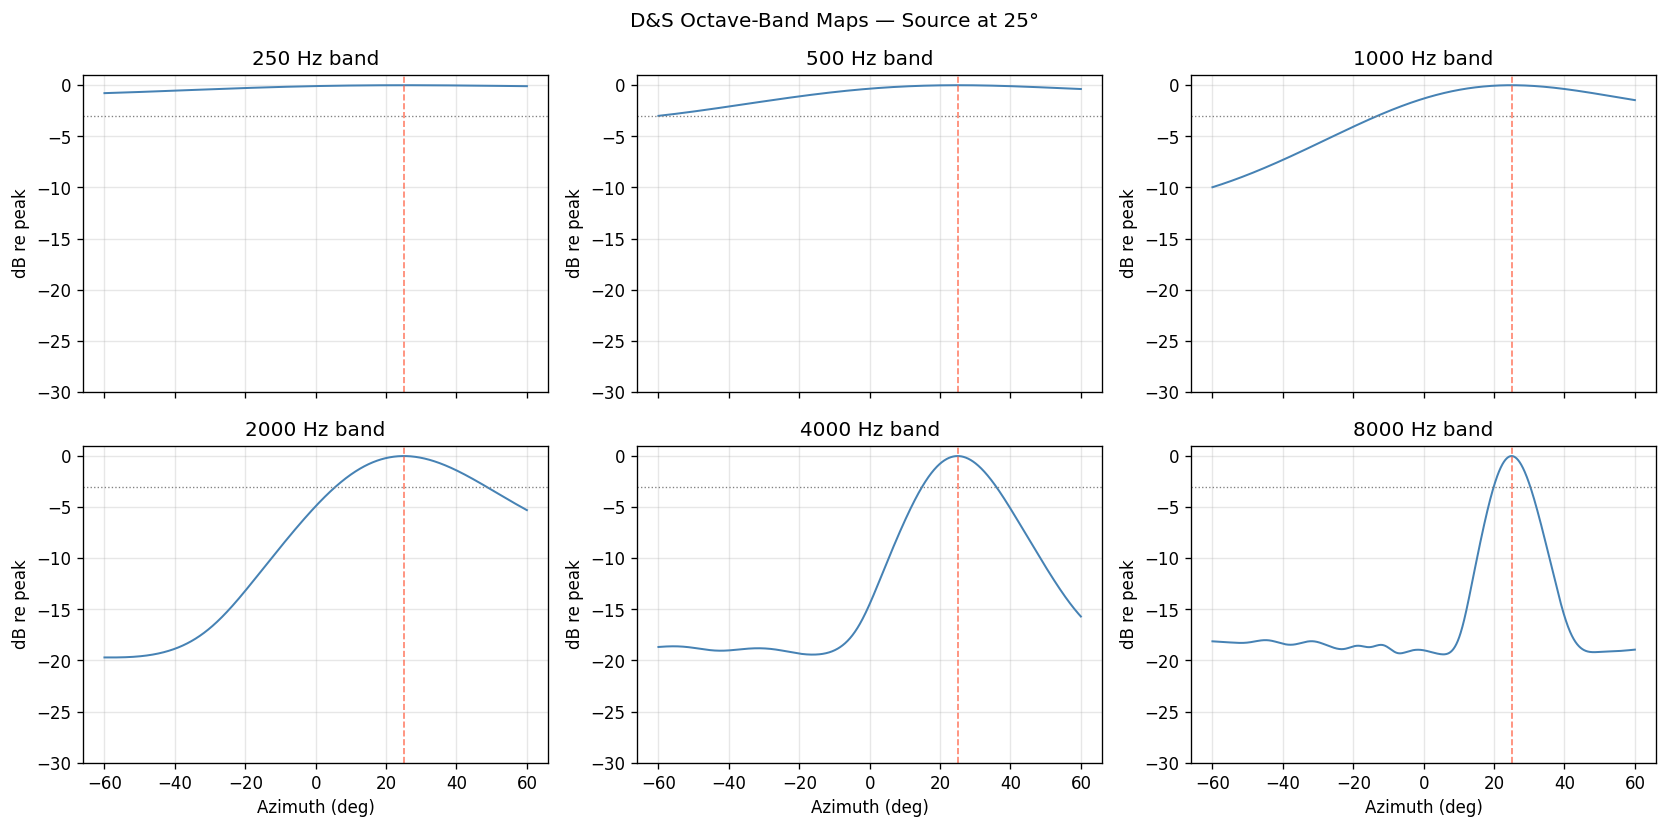

In [5]:
# Standard octave bands (ISO 266), center frequencies in Hz
OCTAVE_CENTERS = np.array([250, 500, 1000, 2000, 4000, 8000])

# 5 log-spaced frequencies per band (within ±0.5 octave of centre)
def octave_freqs(f_center, n_per_band=5):
    return np.geomspace(f_center / np.sqrt(2), f_center * np.sqrt(2), n_per_band)


def broadband_map_ds(x, y, sources, f_center, snr_db=20, n_snap=N_SNAP, n_per_band=5):
    # Incoherently average D&S maps across n_per_band frequencies in one octave band
    freqs = octave_freqs(f_center, n_per_band)
    az = np.linspace(-60, 60, 1201)
    maps = [beamform_ds(x, y, make_csm(x, y, sources, f, snr_db, n_snap), f, az)
            for f in freqs]
    return az, np.mean(maps, axis=0)


# Single broadband source at 25 degrees
src_bb = [(25.0, 1.0)]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
az_plot = np.linspace(-60, 60, 1201)

for ax, fc in zip(axes.flat, OCTAVE_CENTERS):
    az_out, map_out = broadband_map_ds(x_arr, y_arr, src_bb, fc, snr_db=20)
    ax.plot(az_out, db_norm(map_out), color='steelblue', linewidth=1.2)
    ax.axvline(25, color='tomato', linestyle='--', linewidth=1, alpha=0.8, label='True az')
    ax.axhline(-3, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(f'{fc} Hz band')
    ax.set_ylim(-30, 1)
    ax.set_ylabel('dB re peak')
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel('Azimuth (deg)')

fig.suptitle('D&S Octave-Band Maps — Source at 25°', fontsize=12)
plt.tight_layout()
plt.savefig('bb_octave_maps.png', dpi=150, bbox_inches='tight')
plt.show()


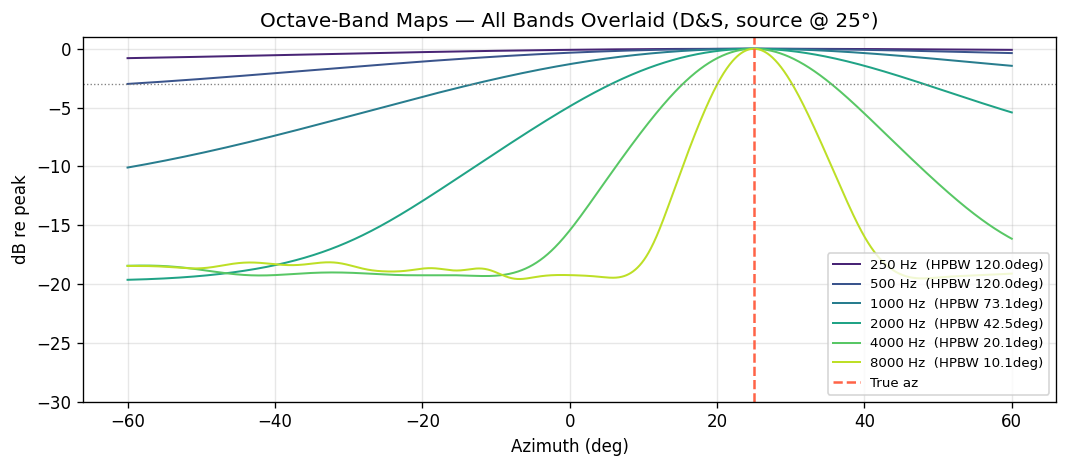

In [6]:
# Overlay all octave maps on one axes to show HPBW narrowing
fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(OCTAVE_CENTERS)))

for fc, color in zip(OCTAVE_CENTERS, colors):
    az_out, map_out = broadband_map_ds(x_arr, y_arr, src_bb, fc, snr_db=20)
    hpbw = measure_hpbw(az_out, map_out)
    ax.plot(az_out, db_norm(map_out), color=color, linewidth=1.2,
            label=f'{fc} Hz  (HPBW {hpbw:.1f}deg)')

ax.axvline(25, color='tomato', linestyle='--', linewidth=1.5, label='True az')
ax.axhline(-3, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Azimuth (deg)')
ax.set_ylabel('dB re peak')
ax.set_title('Octave-Band Maps — All Bands Overlaid (D&S, source @ 25°)')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(-30, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb_octave_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 — Algorithm Comparison Across Octave Bands

Two sources at −15° and +15° (30° separation).  At low frequencies the
HPBW exceeds the source separation — no algorithm can resolve them.  The
cross-over frequency where resolution is possible is a fundamental limit of
the aperture, not of the algorithm.

MVDR and MUSIC are expected to resolve the sources at a lower frequency
than D&S (super-resolution behaviour).


In [7]:
src_two = [(-15.0, 1.0), (15.0, 1.0)]
az_fine = np.linspace(-60, 60, 3601)


def is_resolved(az_grid, beam_map, az1=-15.0, az2=15.0, threshold_db=-6):
    # Two peaks are 'resolved' if the valley between them is > threshold_db below peak
    i1 = np.argmin(np.abs(az_grid - az1))
    i2 = np.argmin(np.abs(az_grid - az2))
    lo, hi = min(i1, i2), max(i1, i2)
    valley = beam_map[lo:hi+1].min()
    return 10 * np.log10(valley / beam_map.max()) < threshold_db


rows = []
for fc in OCTAVE_CENTERS:
    R = make_csm(x_arr, y_arr, src_two, fc, snr_db=20)
    m_ds    = beamform_ds(x_arr, y_arr, R, fc, az_fine)
    m_mvdr  = beamform_mvdr(x_arr, y_arr, R, fc, az_fine)
    m_music = beamform_music(x_arr, y_arr, R, fc, az_fine, n_sources=2)
    rows.append({
        'Band (Hz)': fc,
        'HPBW (D&S)': f'{measure_hpbw(az_fine, m_ds):.1f}',
        'D&S': 'Yes' if is_resolved(az_fine, m_ds) else 'No',
        'MVDR': 'Yes' if is_resolved(az_fine, m_mvdr) else 'No',
        'MUSIC': 'Yes' if is_resolved(az_fine, m_music) else 'No',
    })

df = pd.DataFrame(rows).set_index('Band (Hz)')
print(df.to_string())


          HPBW (D&S)  D&S MVDR MUSIC
Band (Hz)                           
250            120.0   No   No    No
500            120.0   No   No    No
1000            95.5   No   No    No
2000            63.1   No  Yes   Yes
4000            50.0   No  Yes   Yes
8000            39.8  Yes  Yes   Yes


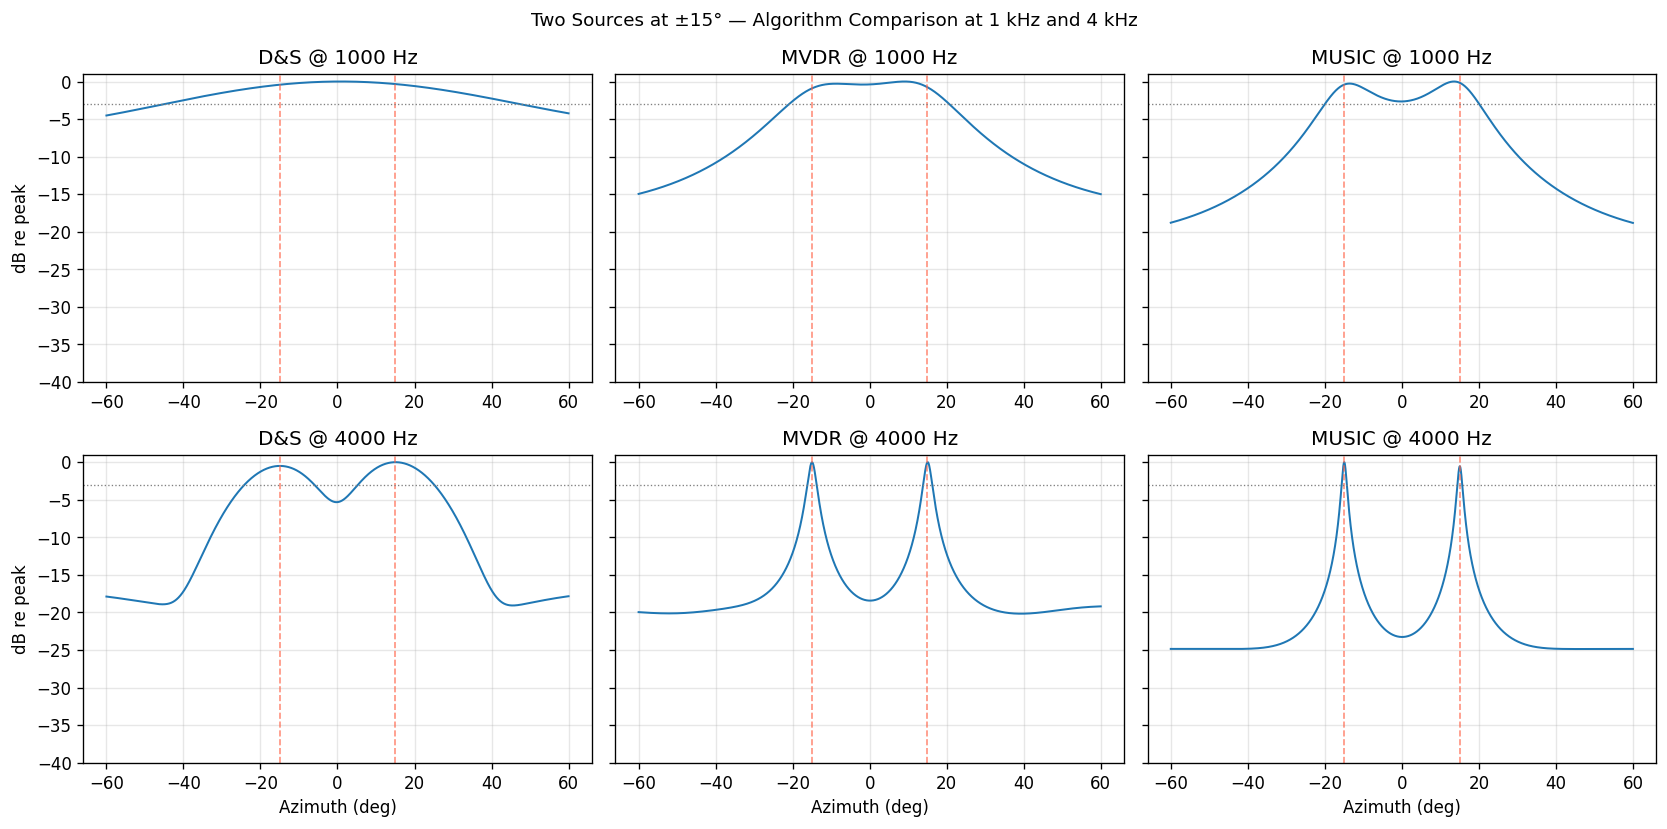

In [8]:
# Visual: show maps at 1 kHz (transitional) and 4 kHz (easy) for all three algorithms
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
algo_names = ['D&S', 'MVDR', 'MUSIC']

for row_idx, fc in enumerate([1000, 4000]):
    R = make_csm(x_arr, y_arr, src_two, fc, snr_db=20)
    maps = [
        beamform_ds(x_arr, y_arr, R, fc, az_fine),
        beamform_mvdr(x_arr, y_arr, R, fc, az_fine),
        beamform_music(x_arr, y_arr, R, fc, az_fine, n_sources=2),
    ]
    for col_idx, (m, name) in enumerate(zip(maps, algo_names)):
        ax = axes[row_idx, col_idx]
        ax.plot(az_fine, db_norm(m), linewidth=1.2)
        for az_true in [-15, 15]:
            ax.axvline(az_true, color='tomato', linestyle='--', linewidth=1, alpha=0.7)
        ax.axhline(-3, color='gray', linestyle=':', linewidth=0.8)
        ax.set_title(f'{name} @ {fc} Hz')
        ax.set_ylim(-40, 1)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel('dB re peak')
        if row_idx == 1:
            ax.set_xlabel('Azimuth (deg)')

fig.suptitle('Two Sources at ±15° — Algorithm Comparison at 1 kHz and 4 kHz', fontsize=11)
plt.tight_layout()
plt.savefig('bb_algo_vs_freq.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 — Spatial Aliasing

Spatial aliasing occurs when the minimum inter-element spacing `d_min`
exceeds half a wavelength: `d_min > λ/2`.  For our array:

    d_min ≈ 12.9 mm  →  alias-free up to c / (2 · d_min) ≈ 13.3 kHz

This is well above our 8 kHz target.  This section:
- Confirms clean operation at 8 kHz
- Shows what aliasing looks like at 16 kHz and 20 kHz (above Nyquist)
- Illustrates that the Underbrink irregular geometry spreads alias energy
  across many weak lobes instead of a single strong grating lobe


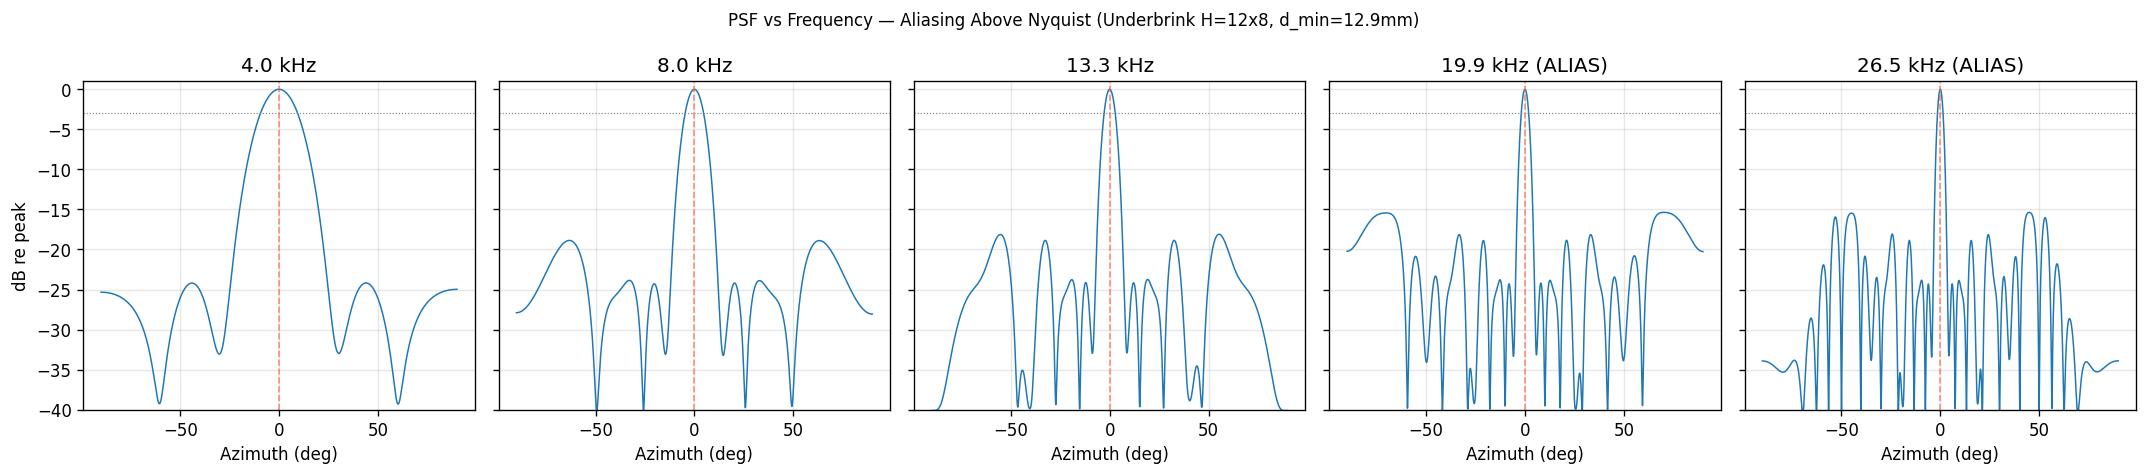

Spatial Nyquist: 13253 Hz  (d_min = 12.9 mm)
Target max freq: 8000 Hz  (margin: 1.66x)


In [9]:
# PSF (single source at 0 deg) at several frequencies including above Nyquist
alias_freqs = [4000, 8000, int(f_nyquist), int(f_nyquist * 1.5), int(f_nyquist * 2)]
az_full = np.linspace(-90, 90, 3601)

fig, axes = plt.subplots(1, len(alias_freqs), figsize=(18, 4), sharey=True)

for ax, f in zip(axes, alias_freqs):
    R = make_csm(x_arr, y_arr, [(0.0, 1.0)], f, snr_db=40)
    m = beamform_ds(x_arr, y_arr, R, f, az_full)
    ax.plot(az_full, db_norm(m), linewidth=0.9)
    ax.axvline(0, color='tomato', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(-3, color='gray', linestyle=':', linewidth=0.7)
    label = f'{f/1000:.1f} kHz'
    if f > f_nyquist:
        label += ' (ALIAS)'
    ax.set_title(label)
    ax.set_ylim(-40, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Azimuth (deg)')

axes[0].set_ylabel('dB re peak')
fig.suptitle('PSF vs Frequency — Aliasing Above Nyquist (Underbrink H=12x8, d_min=12.9mm)',
             fontsize=10)
plt.tight_layout()
plt.savefig('bb_aliasing.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Spatial Nyquist: {f_nyquist:.0f} Hz  (d_min = {d_min*1e3:.1f} mm)')
print(f'Target max freq: 8000 Hz  (margin: {f_nyquist/8000:.2f}x)')


## Summary


In [10]:
rows_hpbw = []
for f in OCTAVE_CENTERS:
    R = make_csm(x_arr, y_arr, src_boresight, f, snr_db=30)
    m = beamform_ds(x_arr, y_arr, R, f, az_grid)
    hpbw = measure_hpbw(az_grid, m)
    rows_hpbw.append({'Freq (Hz)': f, 'HPBW D&S (deg)': round(hpbw, 1)})

df_hpbw = pd.DataFrame(rows_hpbw).set_index('Freq (Hz)')
print('=== D&S HPBW vs Octave Band ===')
print(df_hpbw.to_string())
print()
print('=== Two-Source Resolution (±15 deg) ===')
print(df.to_string())
print()
print(f'Spatial Nyquist: {f_nyquist:.0f} Hz  |  8 kHz target margin: {f_nyquist/8000:.1f}x')


=== D&S HPBW vs Octave Band ===
           HPBW D&S (deg)
Freq (Hz)                
250                 180.0
500                 180.0
1000                 81.8
2000                 38.2
4000                 18.8
8000                  9.3

=== Two-Source Resolution (±15 deg) ===
          HPBW (D&S)  D&S MVDR MUSIC
Band (Hz)                           
250            120.0   No   No    No
500            120.0   No   No    No
1000            95.5   No   No    No
2000            63.1   No  Yes   Yes
4000            50.0   No  Yes   Yes
8000            39.8  Yes  Yes   Yes

Spatial Nyquist: 13253 Hz  |  8 kHz target margin: 1.7x
